# Bouquet systematics check — pinned σ=0 / pinned IDA-σ / production

Runs the bouquet **three times** to expose any inherent bias or systematic offset:

1. **j_phi pinned, σ=0** — every draw must reproduce the baseline (boundary ~0 mm, coil drift ~0 %). This is the strict no-systematic floor.
2. **j_phi pinned, IDA-like σ** — only the pressure profile perturbs; the response should be symmetric about the baseline.
3. **production** — free j_phi + IDA σ, the full bouquet.

After each mode we draw the same traces + coil-current diagnostics as the main example and print **signed** drift means — a non-zero mean is a bias; symmetric scatter (mean ≈ 0) is healthy.

> This notebook always regenerates (it is a validation run). It writes one `.h5` per mode and does not touch the golden draws.

## 1. Imports

In [1]:
import sys, os

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# --- TokaMaker (OpenFUSIONToolkit must be importable, e.g. on PYTHONPATH) ---
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun

# --- Bouquet ---
import bouquet
from bouquet import (
    read_geqdsk, reconstruct_equilibrium, generate_bouquet,
    initialize_equilibrium_database, store_equilibrium,
    synthetic_ida_sigma,
    plot_bouquet, plot_traces, plot_boundary_point_traces,
    plot_geqdsk_bouquet, plot_pfile_bouquet, plot_coil_currents,
    plot_tokamaker_comparison, GEQDSKEquilibrium,
)
from bouquet import (filter_coil_currents, filter_boundaries,
                     select_indices, export_filtered)
from bouquet.io.pfile import read_pfile
print("bouquet:", bouquet.__file__)

bouquet: /Users/danielburgess/Desktop/plasma/bouquet/bouquet/__init__.py


## 2. Configuration

In [2]:
import numpy as np
# ---- input files (shipped here) ----
GEQ  = 'D3Dlike_Hmode_baseline.geqdsk'
PF   = 'D3Dlike_Hmode_baseline.peqdsk'
MESH = 'DIIID_mesh.h5'

# ---- run controls ----
n_equils = 10        # draws per mode
seed     = 12345     # reproducible draws (modes 2 & 3 share the GPR sequence)

# ---- perturbation / GPR settings (identical to the main example) ----
pad_psi   = 1e-4
n_ls, t_ls, j_ls = 0.5, 0.4, 0.25
frac_jphi = 0.10
jBS_scale_range = [0.99, 1.01]
l_i_tolerance   = 0.05

# ---- coil-drift / homotopy / in-spec (fractions) ----
coil_drift      = 0.01
homotopy_passes = [(0.05, 0.10), (0.02, 0.05), (0.01, 0.01)]
inspec_F_max    = 0.02
inspec_VSC_max  = 0.02
vsc_soft_reg_weight = 1.0
p_thresh        = 0.05
ion_N, ion_Z, ion_A = [6, 1, 1], [6, 1, 1], [12, 2, 2]

# ---- the three modes: (header, sigma_scale, pin_jphi, label) ----
MODES = [
    ('D3Dlike_sys_pinned_s0',  0.0, True,  'pinned, sigma=0'),
    ('D3Dlike_sys_pinned_ida', 1.0, True,  'pinned, IDA sigma'),
    ('D3Dlike_sys_production', 1.0, False, 'production (free j_phi + IDA sigma)'),
]
print('modes:', [m[3] for m in MODES], ' n_equils =', n_equils)

modes: ['pinned, sigma=0', 'pinned, IDA sigma', 'production (free j_phi + IDA sigma)']  n_equils = 10


## 3. Load baseline + kinetic profiles + σ envelopes

In [3]:
eqdsk = read_geqdsk(GEQ, cocos=1)
psi_N = eqdsk.psi_N
F0 = abs(eqdsk.R_center * eqdsk.B_center)   # |F0| for the solve (sign handled by file)

pf = read_pfile(PF)
if pf.ion_species is None:
    pf.set_ion_species(N=ion_N, Z=ion_Z, A=ion_A)
pf.compute_quasineutrality()
psi_pf, Zeff = pf.compute_zeff()

# SI profiles on the equilibrium psi_N grid (for reconstruction)
ne_SI = interp1d(psi_pf, pf.ne*1e20, fill_value='extrapolate')(psi_N)   # m^-3
te_SI = interp1d(psi_pf, pf.te*1e3,  fill_value='extrapolate')(psi_N)   # eV
ni_SI = interp1d(psi_pf, pf.ni*1e20, fill_value='extrapolate')(psi_N)
ti_SI = interp1d(psi_pf, pf.ti*1e3,  fill_value='extrapolate')(psi_N)
Zeff_eq = np.clip(interp1d(psi_pf, Zeff, fill_value='extrapolate')(psi_N), 1.0, None)

print(f"Ip = {eqdsk.Ip:+.3e} A   Bt = {eqdsk.B_center:+.3f} T   F0 = {F0:.4f}")
print(f"ne0 = {ne_SI[0]:.3e} m^-3   Te0 = {te_SI[0]:.0f} eV   Ti0 = {ti_SI[0]:.0f} eV")

Ip = +1.200e+06 A   Bt = -2.008 T   F0 = 3.3910
ne0 = 5.500e+19 m^-3   Te0 = 2500 eV   Ti0 = 5000 eV


In [4]:
# Kinetic-grid profiles + IDA-like fractional sigma envelopes (sigma_jphi is
# built per mode inside run_mode, since it scales recon's j_phi_fit).
ne_kin = pf.ne*1e20; te_kin = pf.te*1e3; ni_kin = pf.ni*1e20; ti_kin = pf.ti*1e3
sig_ne = synthetic_ida_sigma(psi_pf, 'ne') * ne_kin
sig_te = synthetic_ida_sigma(psi_pf, 'te') * te_kin
sig_ni = synthetic_ida_sigma(psi_pf, 'ni') * ni_kin
sig_ti = synthetic_ida_sigma(psi_pf, 'ti') * ti_kin
print('sigma envelopes built on', len(psi_pf), 'psi pts')

sigma envelopes built on 514 psi pts


## 4. Initialize TokaMaker

In [5]:
# nthreads=1: bit-reproducible solves, no BLAS oversubscription.
myOFT = OFT_env(nthreads=int(os.environ.get('NTHREADS', '1')))
mygs  = TokaMaker(myOFT)
mp, ml, mr, cd, cnd = load_gs_mesh(MESH)
mygs.setup_mesh(mp, ml, mr)
mygs.setup_regions(cond_dict=cnd, coil_dict=cd)
mygs.setup(order=3, F0=F0)
mygs.settings.maxits = 800
mygs.settings.pm = False
mygs.update_settings()
mygs.set_coil_vsc({'F9A': 1.0, 'F9B': -1.0})

# Weak regularization toward zero -> free inverse solve finds the coil currents
reg = [mygs.coil_reg_term({n: 1.0}, target=0.0, weight=1.0) for n in mygs.coil_sets]
reg.append(mygs.coil_reg_term({'#VSC': 1.0}, target=0.0, weight=1e-2))
mygs.set_coil_reg(reg_terms=reg)

iso = np.column_stack([eqdsk.boundary_R, eqdsk.boundary_Z])
isow = np.ones(len(iso)) * 200.0
mygs.set_isoflux(iso, weights=isow)
print(f"TokaMaker ready: {len(mp)} mesh pts, {len(mygs.coil_sets)} coil sets")

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.6
Development branch:  fix/bootstrap-pchip-derivatives
Revision id:         19e08b2

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    1

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    8910
    # of edges   =   26567
    # of cells   =   17658
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  8.702E-04
    hrms =  4.833E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1733


**** Creating Lagrange FE space
  Order  =    3
  Minlev =   -1


 Inverting real matrix
   Time =    1.6379999999999999E-003


TokaMaker ready: 8910 mesh pts, 20 coil sets


/var/folders/wz/x_qd5n8d62s0qj0_kcyyqf780000gn/T/ipykernel_34485/2826624946.py:20: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(iso, weights=isow)


## 5. Helper: run one mode (reconstruct + generate) + summary

In [6]:
def run_mode(header, sigma_scale, pin_jphi):
    """Fresh reconstruct (identical baseline every mode) + one bouquet."""
    mygs.set_isoflux(iso, weights=isow)
    guess = create_power_flux_fun(len(psi_N), 1.5, 1.5)['y']
    result = reconstruct_equilibrium(
        mygs, eqdsk, ne_SI, te_SI, ni_SI, ti_SI, Zeff_eq, iso, isow, pad_psi,
        guess_jinductive=guess, n_k=5, psi_bridge=0.99, rescale_j_BS=False,
        shelf_psi_N=0.0, initialize_psi=True)
    Ip_target  = abs(eqdsk.Ip)
    l_i_target = float(mygs.get_stats(lcfs_pad=pad_psi, li_normalization='std')['l_i'])
    sigma_jphi = frac_jphi * np.abs(result['j_phi_fit'])

    if os.path.exists(header + '.h5'):
        os.remove(header + '.h5')
    initialize_equilibrium_database(header)
    with open(GEQ, 'rb') as fh: geq_raw = fh.read()
    with open(PF,  'rb') as fh: pf_raw  = fh.read()
    mygs.set_isoflux(result['isoflux_pts'], weights=result['weights'])

    diag = generate_bouquet(
        mygs, psi_N, n_equils, header,
        result['j_phi_fit'],
        ne_kin, te_kin, ni_kin, ti_kin,
        sig_ne*sigma_scale, sig_te*sigma_scale,
        sig_ni*sigma_scale, sig_ti*sigma_scale, sigma_jphi*sigma_scale,
        n_ls, t_ls, j_ls,
        Ip_target, l_i_target, Zeff_eq,
        input_jinductive=result['j_inductive_fit'],
        l_i_tolerance=l_i_tolerance, psi_pad=pad_psi,
        constrain_sawteeth=False, recalculate_j_BS=True,
        jBS_scale_range=jBS_scale_range,
        pfile_bytes=pf_raw, baseline_eqdsk_bytes=geq_raw, baseline_pfile_bytes=pf_raw,
        diagnostic_plots=False, scan_key=0, psi_N_kinetic=psi_pf,
        coil_drift=coil_drift, homotopy_passes=homotopy_passes,
        inspec_F_max=inspec_F_max, inspec_VSC_max=inspec_VSC_max,
        p_thresh=p_thresh, vsc_soft_reg_weight=vsc_soft_reg_weight,
        save_truncate_eq=True, jphi_baseline=True, seed=seed, pin_jphi=pin_jphi,
    )
    print(f"  -> {len(diag)} draws archived in {header}.h5")
    return result, diag


def systematics_summary(header, label):
    """Signed coil drift + boundary RMS -- a bias is a non-zero MEAN."""
    import h5py, json as _json
    from scipy.spatial import cKDTree
    with h5py.File(header + '.h5', 'r') as f:
        g = f['scan/0']; bl = g['_baseline']
        bln = [(n.decode() if isinstance(n, bytes) else str(n))
               for n in bl['coil_names'][()]]
        base = dict(zip(bln, np.array(bl['coil_currents'])))
        draws = sorted(int(k) for k in g if k.isdigit())
        def drift(coil):
            out = []
            for i in draws:
                nm = [n.decode() if isinstance(n, bytes) else str(n) for n in g[str(i)]['coil_names'][()]]
                v  = np.array(g[str(i)]['coil_currents'])
                out.append(100*(dict(zip(nm, v))[coil] - base[coil])
                           / abs(base[coil]))
            return np.array(out)
        ref = np.asarray(bl['recon_lcfs_ref'][()]) if 'recon_lcfs_ref' in bl else None
        rms = []
        for i in draws:
            gi = g[str(i)]
            if ref is not None and 'perturbed_lcfs_ref' in gi:
                p = np.asarray(gi['perturbed_lcfs_ref'][()])
                d, _ = cKDTree(p).query(ref)
                rms.append(np.sqrt((d**2).mean())*1e3)
        inspec = sum(1 for i in draws if bool(g[str(i)].attrs.get('in_spec')))
        f9a, f9b = drift('F9A'), drift('F9B')
        fco = [n for n in bln if n.startswith('F') and n not in ('F9A', 'F9B')]
        allF = np.concatenate([drift(c) for c in fco]) if fco else np.array([0.0])
    rms = np.array(rms) if rms else np.array([np.nan])
    print(f"[{label}]  draws={len(draws)}  in-spec={inspec}/{len(draws)}")
    print(f"   boundary RMS [mm] : median {np.nanmedian(rms):.4f}  max {np.nanmax(rms):.4f}")
    print(f"   F9A drift %       : mean {f9a.mean():+.4f}  std {f9a.std():.4f}  (mean~0 => no bias)")
    print(f"   F9B drift %       : mean {f9b.mean():+.4f}  std {f9b.std():.4f}")
    print(f"   non-VSC F drift % : mean {allF.mean():+.5f}  std {allF.std():.4f}")
    return dict(label=label, n=len(draws), inspec=inspec,
                bnd_rms_med=float(np.nanmedian(rms)),
                bnd_rms_max=float(np.nanmax(rms)),
                f9a_mean=float(f9a.mean()), f9b_mean=float(f9b.mean()),
                allF_mean=float(allF.mean()))

summaries = {}

## 6. Mode 1 — j_phi pinned, σ=0  (no-systematic floor)

In [7]:
m = MODES[0]
print('=== MODE 1:', m[3], '===')
res, diag = run_mode(m[0], m[1], m[2])

/var/folders/wz/x_qd5n8d62s0qj0_kcyyqf780000gn/T/ipykernel_34485/2822994751.py:3: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(iso, weights=isow)


=== MODE 1: pinned, sigma=0 ===



 >>> Matching input core j_phi with G-S solution



 >>> Finding optimal j_phi scale factor

--- Checking scale_j0 = 1.0000 ---


   Input j_0:  1.1899e+06
   Output j_0: 1.2552e+06
   Mismatch:  5.202%

--- Checking scale_j0 = 1.2000 ---


...

Bouquet:  90%|█████████ | 9/10 [03:54<00:23, 23.54s/eq, avg=22s/eq, total=3.9min]

  [homotopy pass 3/3] F=+/-1.0%  VSC=+/-1.0% -> SOLVED (max non-VSC F-coil drift=0.00%, max VSC drift=0.00%)
  [bnd-diag] after homotopy           vs recon LCFS: rms=  0.45 mm  max=  4.15 mm
  [in-spec] IN_SPEC: max non-VSC F-drift=0.00% (limit 2.0%), max VSC drift=0.00% (limit 2.0%)
  Wall-clock time: 22.2s  (total: 3.9 min, avg: 22.1s/eq)
  Saving to: /Users/danielburgess/Desktop/plasma/bouquet/examples/D3D-like/D3Dlike_sys_pinned_s0_count=9.geqdsk
Saving gEQDSK: D3Dlike_sys_pinned_s0_count=9.geqdsk


Bouquet: 100%|██████████| 10/10 [03:55<00:00, 23.56s/eq, avg=22s/eq, total=3.9min]

Bouquet: 100%|██████████| 10/10 [03:55<00:00, 23.56s/eq, avg=22s/eq, total=3.9min]

  Deleted temporary file: /Users/danielburgess/Desktop/plasma/bouquet/examples/D3D-like/D3Dlike_sys_pinned_s0_count=9.geqdsk
  -> 10 draws archived in D3Dlike_sys_pinned_s0.h5


[pinned, sigma=0]  draws=10  in-spec=10/10
   boundary RMS [mm] : median 0.4416  max 0.4443
   F9A drift %       : mean +0.0005  std 0.0001  (mean~0 => no bias)
   F9B drift %       : mean -0.0000  std 0.0001
   non-VSC F drift % : mean +0.00028  std 0.0008


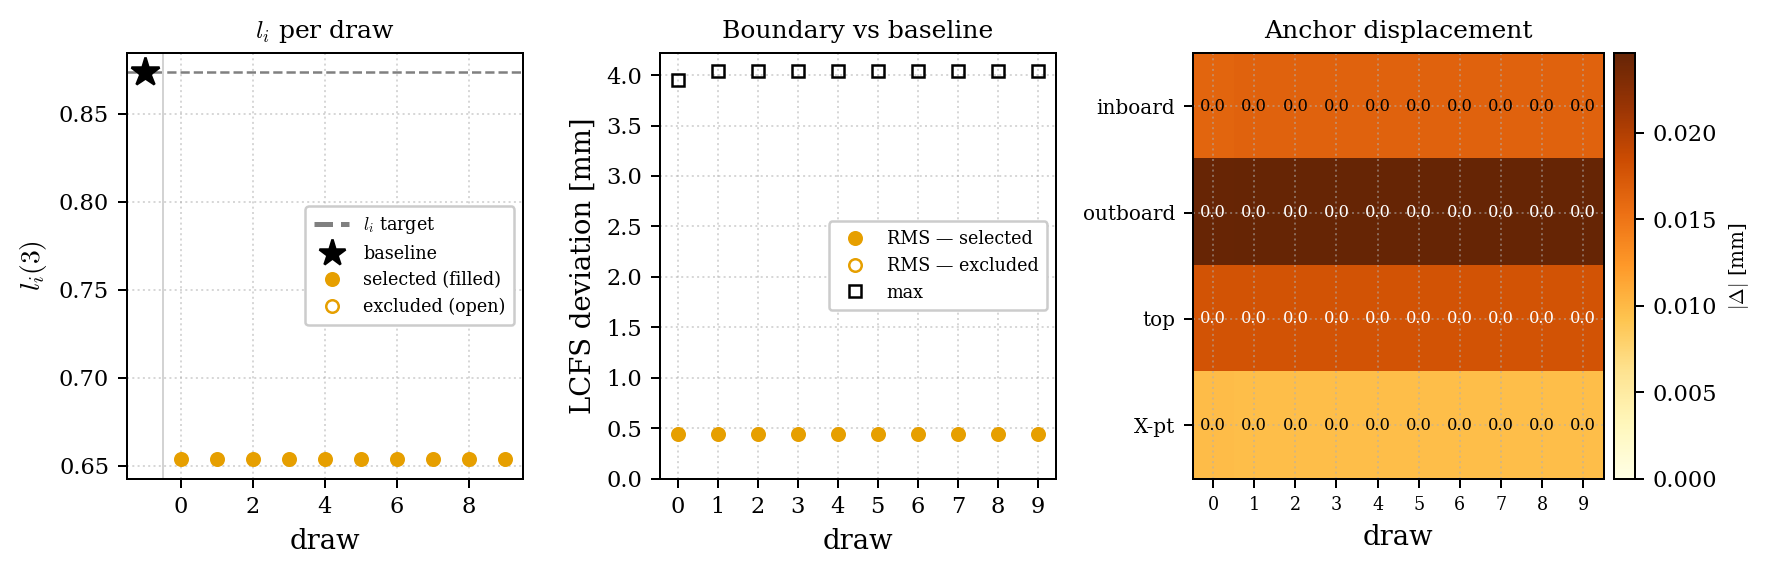

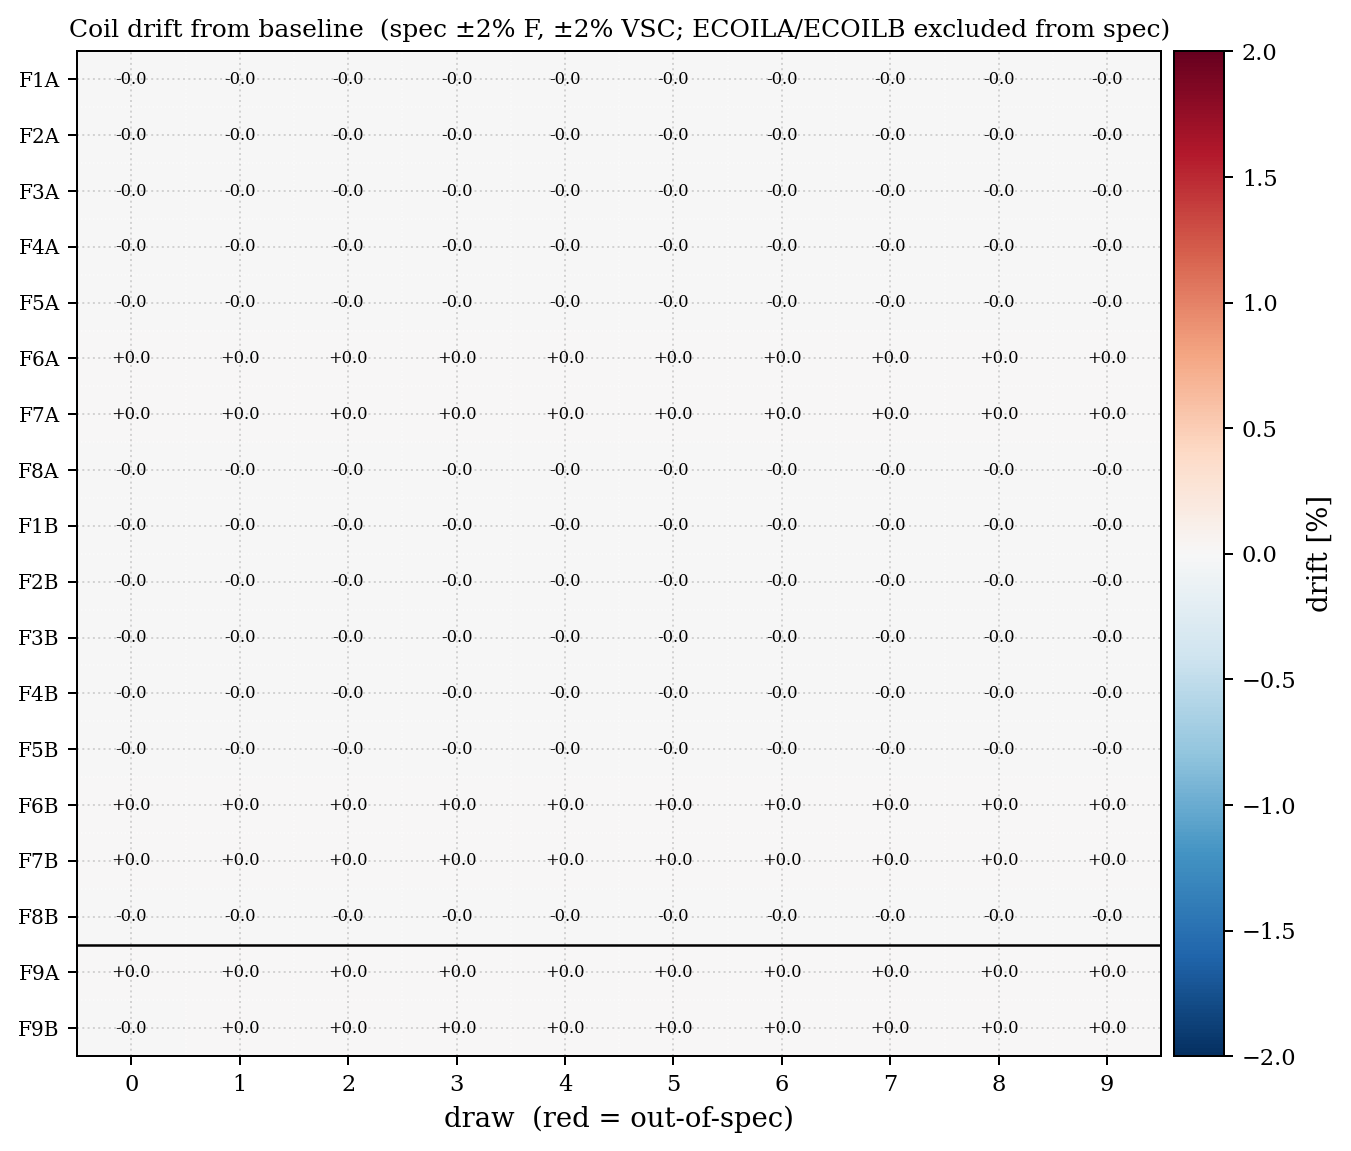

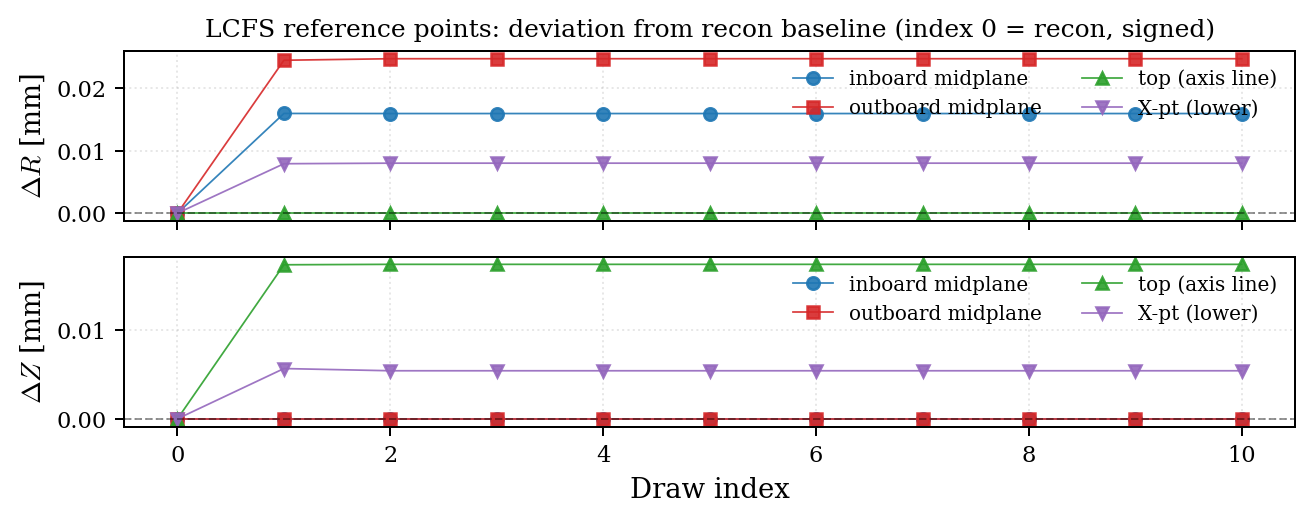

In [8]:
# traces, coil currents, and boundary-point traces for this mode
_h = MODES[0][0]
plot_traces(_h, scan_key='all')
plot_coil_currents(_h, scan_key=0)
plot_boundary_point_traces(_h)
summaries[MODES[0][3].split(' (')[0]] = systematics_summary(_h, MODES[0][3])
import matplotlib.pyplot as plt; plt.show()

## 7. Mode 2 — j_phi pinned, IDA-like σ

In [9]:
m = MODES[1]
print('=== MODE 2:', m[3], '===')
res, diag = run_mode(m[0], m[1], m[2])

=== MODE 2: pinned, IDA sigma ===


/var/folders/wz/x_qd5n8d62s0qj0_kcyyqf780000gn/T/ipykernel_34485/2822994751.py:3: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(iso, weights=isow)



 >>> Matching input core j_phi with G-S solution



 >>> Finding optimal j_phi scale factor

--- Checking scale_j0 = 1.0000 ---


   Input j_0:  1.1798e+06
   Output j_0: 1.1841e+06
   Mismatch:  0.366%

 >>> Iterating on H-mode equilibrium solution


...

Bouquet:  90%|█████████ | 9/10 [04:58<00:31, 31.87s/eq, avg=29s/eq, total=5.0min]

  [homotopy pass 2/3] F=+/-2.0%  VSC=+/-5.0% -> SOLVED (max non-VSC F-coil drift=0.13%, max VSC drift=1.77%)
  [homotopy pass 2/3] natural drift (F=0.13%, VSC=1.77%) exceeds next-pass bound (F=+/-1.0%, VSC=+/-1.0%) -> stop (skip infeasible tighter pass)
  [bnd-diag] after homotopy           vs recon LCFS: rms=  6.02 mm  max= 11.20 mm
  [in-spec] IN_SPEC: max non-VSC F-drift=0.13% (limit 2.0%), max VSC drift=1.54% (limit 2.0%)
  Wall-clock time: 18.9s  (total: 5.0 min, avg: 28.6s/eq)
  Saving to: /Users/danielburgess/Desktop/plasma/bouquet/examples/D3D-like/D3Dlike_sys_pinned_ida_count=9.geqdsk
Saving gEQDSK: D3Dlike_sys_pinned_ida_count=9.geqdsk


Bouquet: 100%|██████████| 10/10 [05:00<00:00, 28.31s/eq, avg=29s/eq, total=5.0min]

Bouquet: 100%|██████████| 10/10 [05:00<00:00, 30.01s/eq, avg=29s/eq, total=5.0min]

  Deleted temporary file: /Users/danielburgess/Desktop/plasma/bouquet/examples/D3D-like/D3Dlike_sys_pinned_ida_count=9.geqdsk
  -> 10 draws archived in D3Dlike_sys_pinned_ida.h5


[pinned, IDA sigma]  draws=10  in-spec=8/10
   boundary RMS [mm] : median 4.8489  max 8.2441
   F9A drift %       : mean +0.0502  std 1.1658  (mean~0 => no bias)
   F9B drift %       : mean -0.0875  std 1.8372
   non-VSC F drift % : mean -0.00149  std 0.0414


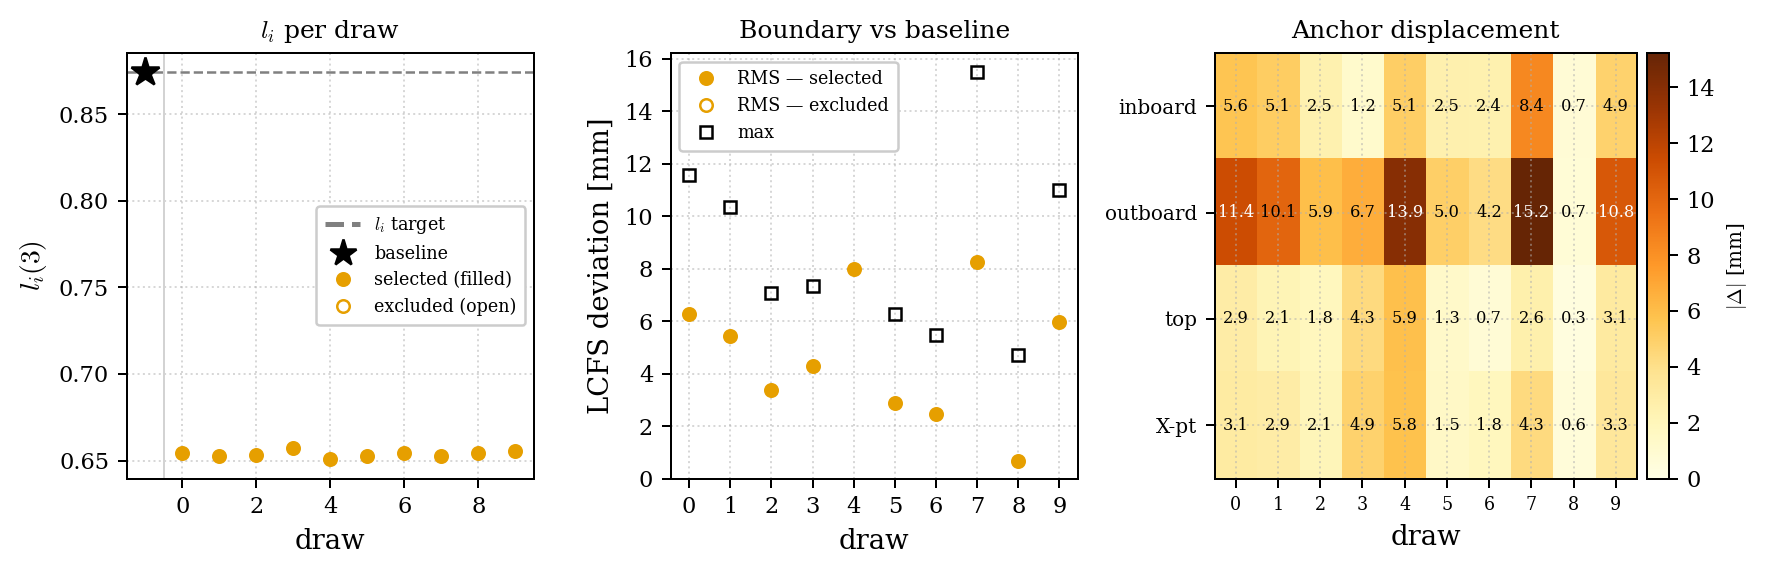

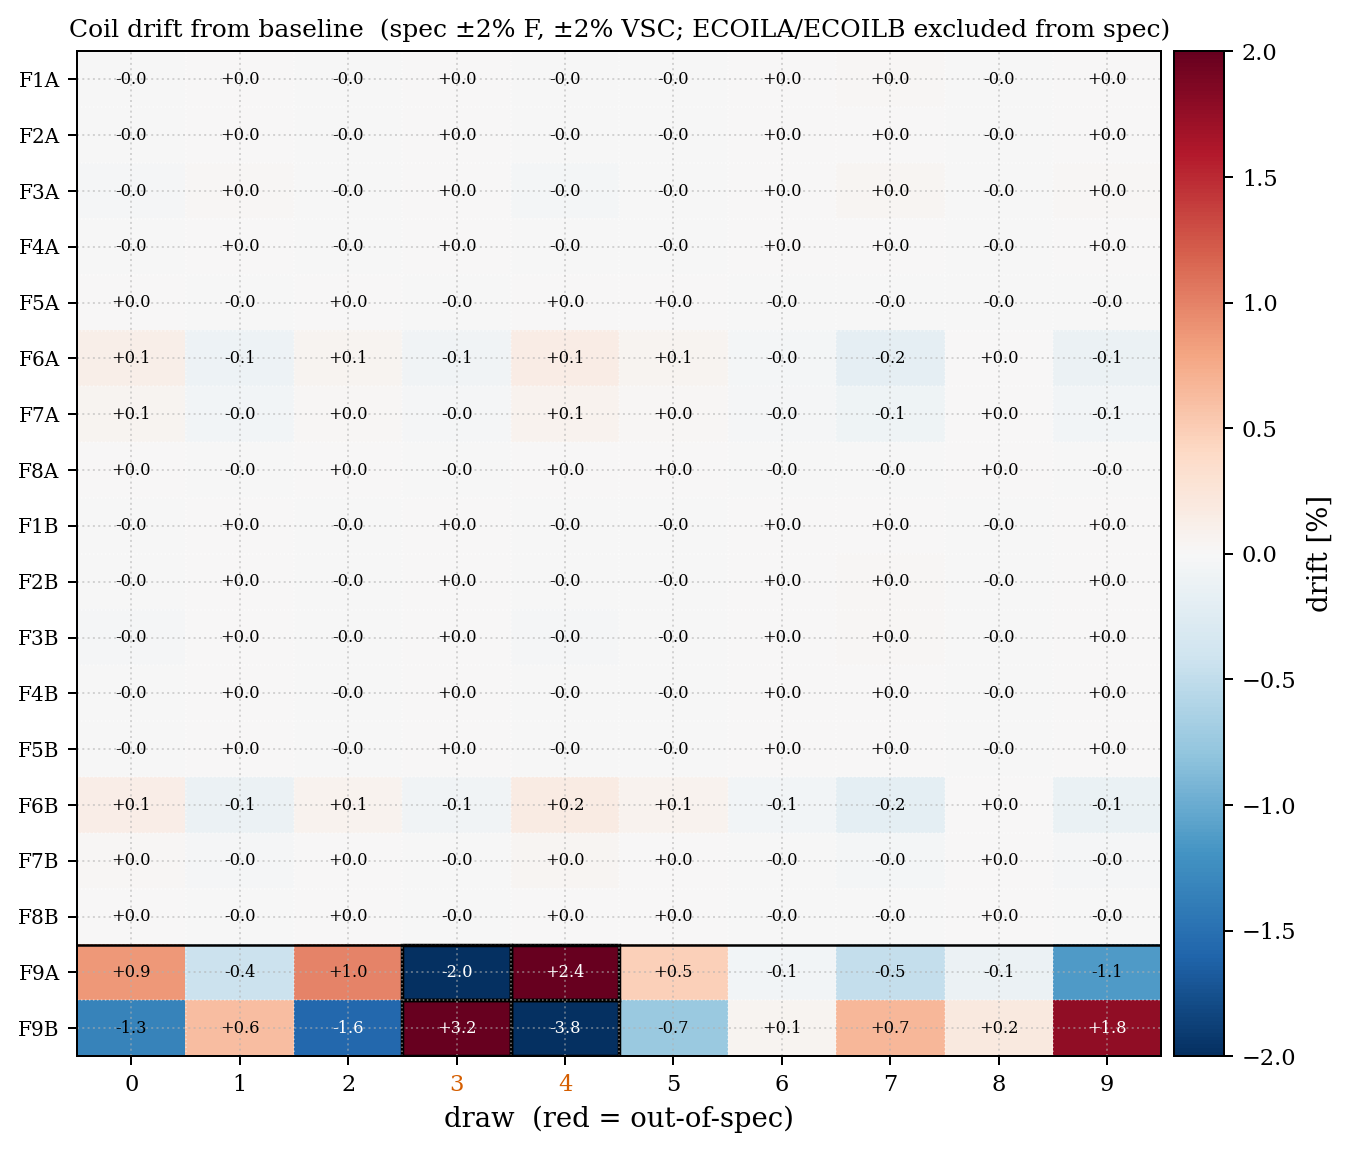

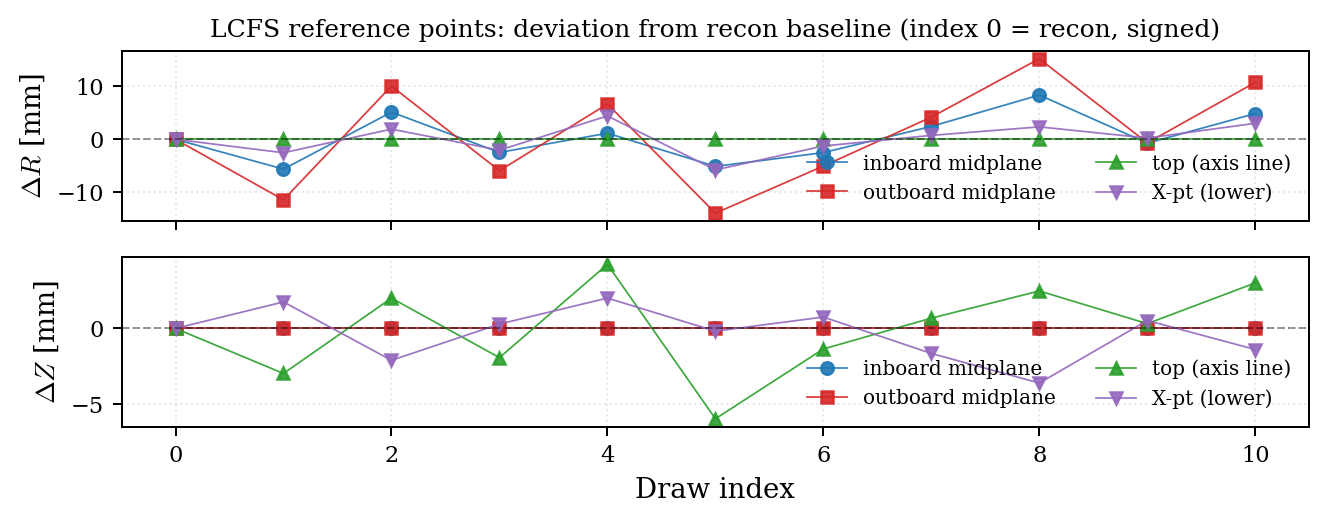

In [10]:
# traces, coil currents, and boundary-point traces for this mode
_h = MODES[1][0]
plot_traces(_h, scan_key='all')
plot_coil_currents(_h, scan_key=0)
plot_boundary_point_traces(_h)
summaries[MODES[1][3].split(' (')[0]] = systematics_summary(_h, MODES[1][3])
import matplotlib.pyplot as plt; plt.show()

## 8. Mode 3 — production (free j_phi + IDA σ)

In [11]:
m = MODES[2]
print('=== MODE 3:', m[3], '===')
res, diag = run_mode(m[0], m[1], m[2])

=== MODE 3: production (free j_phi + IDA sigma) ===


/var/folders/wz/x_qd5n8d62s0qj0_kcyyqf780000gn/T/ipykernel_34485/2822994751.py:3: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(iso, weights=isow)



 >>> Matching input core j_phi with G-S solution



 >>> Finding optimal j_phi scale factor

--- Checking scale_j0 = 1.0000 ---


   Input j_0:  1.1798e+06
   Output j_0: 1.1842e+06
   Mismatch:  0.366%

 >>> Iterating on H-mode equilibrium solution


...

  [jphi correction] 4 iterations, edge RMS: 0.0091 → 0.0011 MA/m²


  l_i target (equil):   0.8742
  proxy target:         1.1824  (corrected)
  matched l_i (equil):  0.6711
  matched l_i (proxy):  0.9076
  Ip error vs target:   0.000%
  proxy vs real l_i:    +35.24%
  l_i error:            23.24% (tolerance: 5.00%)
  [li_iter=12] GPR draw (1 tries, 0 pre-screen-skipped, 0.1s)


Bouquet: 14eq [1:03:28, 299.80s/eq]

Bouquet: 100%|██████████| 10/10 [1:03:28<00:00, 380.87s/eq]


  STOPPED: ValueError: Error in solve: Exceeded "maxits"
  Skipping equilibrium 10/10.
  reset mygs to recon baseline (psi + coils + bounds re-applied).
  -> 0 draws archived in D3Dlike_sys_production.h5


No coil current data found in the HDF5 file.
[production (free j_phi + IDA sigma)]  draws=0  in-spec=0/0
   boundary RMS [mm] : median nan  max nan
   F9A drift %       : mean +nan  std nan  (mean~0 => no bias)
   F9B drift %       : mean +nan  std nan
   non-VSC F drift % : mean +nan  std nan


/var/folders/wz/x_qd5n8d62s0qj0_kcyyqf780000gn/T/ipykernel_34485/2822994751.py:75: RuntimeWarning: All-NaN slice encountered
  print(f"   boundary RMS [mm] : median {np.nanmedian(rms):.4f}  max {np.nanmax(rms):.4f}")
/var/folders/wz/x_qd5n8d62s0qj0_kcyyqf780000gn/T/ipykernel_34485/2822994751.py:76: RuntimeWarning: Mean of empty slice
  print(f"   F9A drift %       : mean {f9a.mean():+.4f}  std {f9a.std():.4f}  (mean~0 => no bias)")
/Users/danielburgess/miniforge3/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/danielburgess/miniforge3/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/danielburgess/miniforge3/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, 

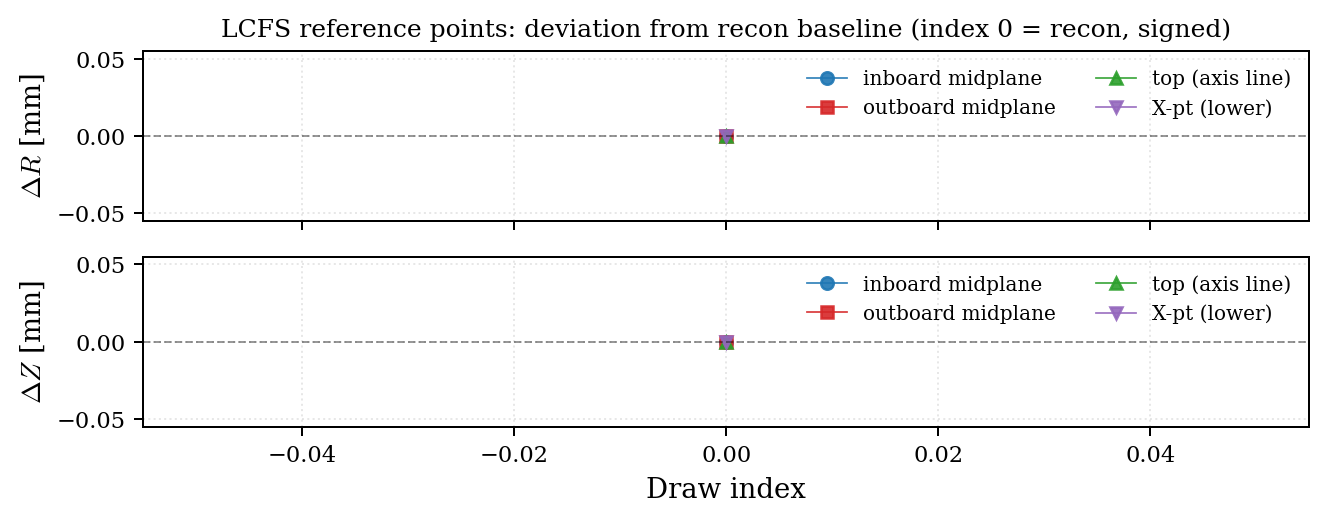

In [12]:
# traces, coil currents, and boundary-point traces for this mode
_h = MODES[2][0]
plot_traces(_h, scan_key='all')
plot_coil_currents(_h, scan_key=0)
plot_boundary_point_traces(_h)
summaries[MODES[2][3].split(' (')[0]] = systematics_summary(_h, MODES[2][3])
import matplotlib.pyplot as plt; plt.show()

## 9. Systematics verdict

In [13]:
# ---- consolidated systematics verdict ----
print('mode'.ljust(38), 'in-spec', 'bnd_rms_med[mm]', 'F9A_mean%', 'F9B_mean%')
for k, s in summaries.items():
    print(s['label'].ljust(38),
          f"{s['inspec']}/{s['n']}".ljust(7),
          f"{s['bnd_rms_med']:.4f}".ljust(15),
          f"{s['f9a_mean']:+.4f}".ljust(9),
          f"{s['f9b_mean']:+.4f}")

# Mode 1 (pinned, sigma=0) is the strict no-systematic floor: every draw
# should reproduce the baseline, so boundary RMS and coil drift must be ~0.
s0 = summaries.get('pinned, sigma=0')
if s0 is not None:
    ok = (s0['bnd_rms_med'] < 0.5 and abs(s0['f9a_mean']) < 0.1
          and abs(s0['f9b_mean']) < 0.1 and abs(s0['allF_mean']) < 0.1)
    print()
    print('NO-SYSTEMATIC FLOOR (pinned sigma=0):',
          'PASS' if ok else 'CHECK -- non-zero offset detected')
# Modes 2 & 3: the signed coil-drift MEANS should sit near zero (symmetric
# scatter); a consistently non-zero mean would indicate a systematic bias.

mode                                   in-spec bnd_rms_med[mm] F9A_mean% F9B_mean%
pinned, sigma=0                        10/10   0.4416          +0.0005   -0.0000
pinned, IDA sigma                      8/10    4.8489          +0.0502   -0.0875
production (free j_phi + IDA sigma)    0/0     nan             +nan      +nan

NO-SYSTEMATIC FLOOR (pinned sigma=0): PASS
